In [1]:
##project 1

In [2]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data
df_y = data.target

In [3]:
import numpy as np

X = np.array(df_X)

print(type(X), X.dtype)

<class 'numpy.ndarray'> float64


In [4]:
y = np.array(df_y)

print(type(y), y.dtype)

<class 'numpy.ndarray'> float64


In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [6]:
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

10


In [7]:
def model(X, W, b): # y = wx + b를 함수로 만들기
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

In [8]:
def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse

In [9]:
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [10]:
def gradient(X, W, b, y): #기울기 함수 구현하기
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

In [11]:
LEARNING_RATE = 0.7  #0.001은 mse값이 목표치에 도달할수없어 학습률을 조정했음

In [12]:
%%timeit -n 1 -r 1
global W, b

losses = []

for i in range(1, 1001):   
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 100 : Loss 3706.1236
Iteration 200 : Loss 3248.1013
Iteration 300 : Loss 3076.5619
Iteration 400 : Loss 2993.9262
Iteration 500 : Loss 2951.2457
Iteration 600 : Loss 2928.4418
Iteration 700 : Loss 2915.8910
Iteration 800 : Loss 2908.7667
Iteration 900 : Loss 2904.5863
Iteration 1000 : Loss 2902.0439
173 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [13]:
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(2874.0735303504052)

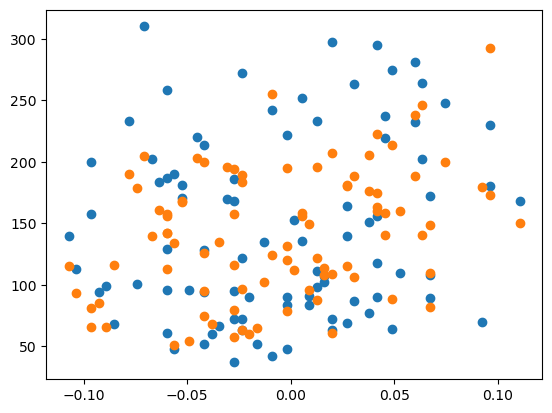

In [14]:
import matplotlib.pyplot as plt

plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()

In [15]:
## project 2

In [16]:
import pandas as pd

train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv") 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [17]:
train['datetime'] = pd.to_datetime(train['datetime'])#먼저 가져온데이터를 자료형으로 변환시켜준다
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-

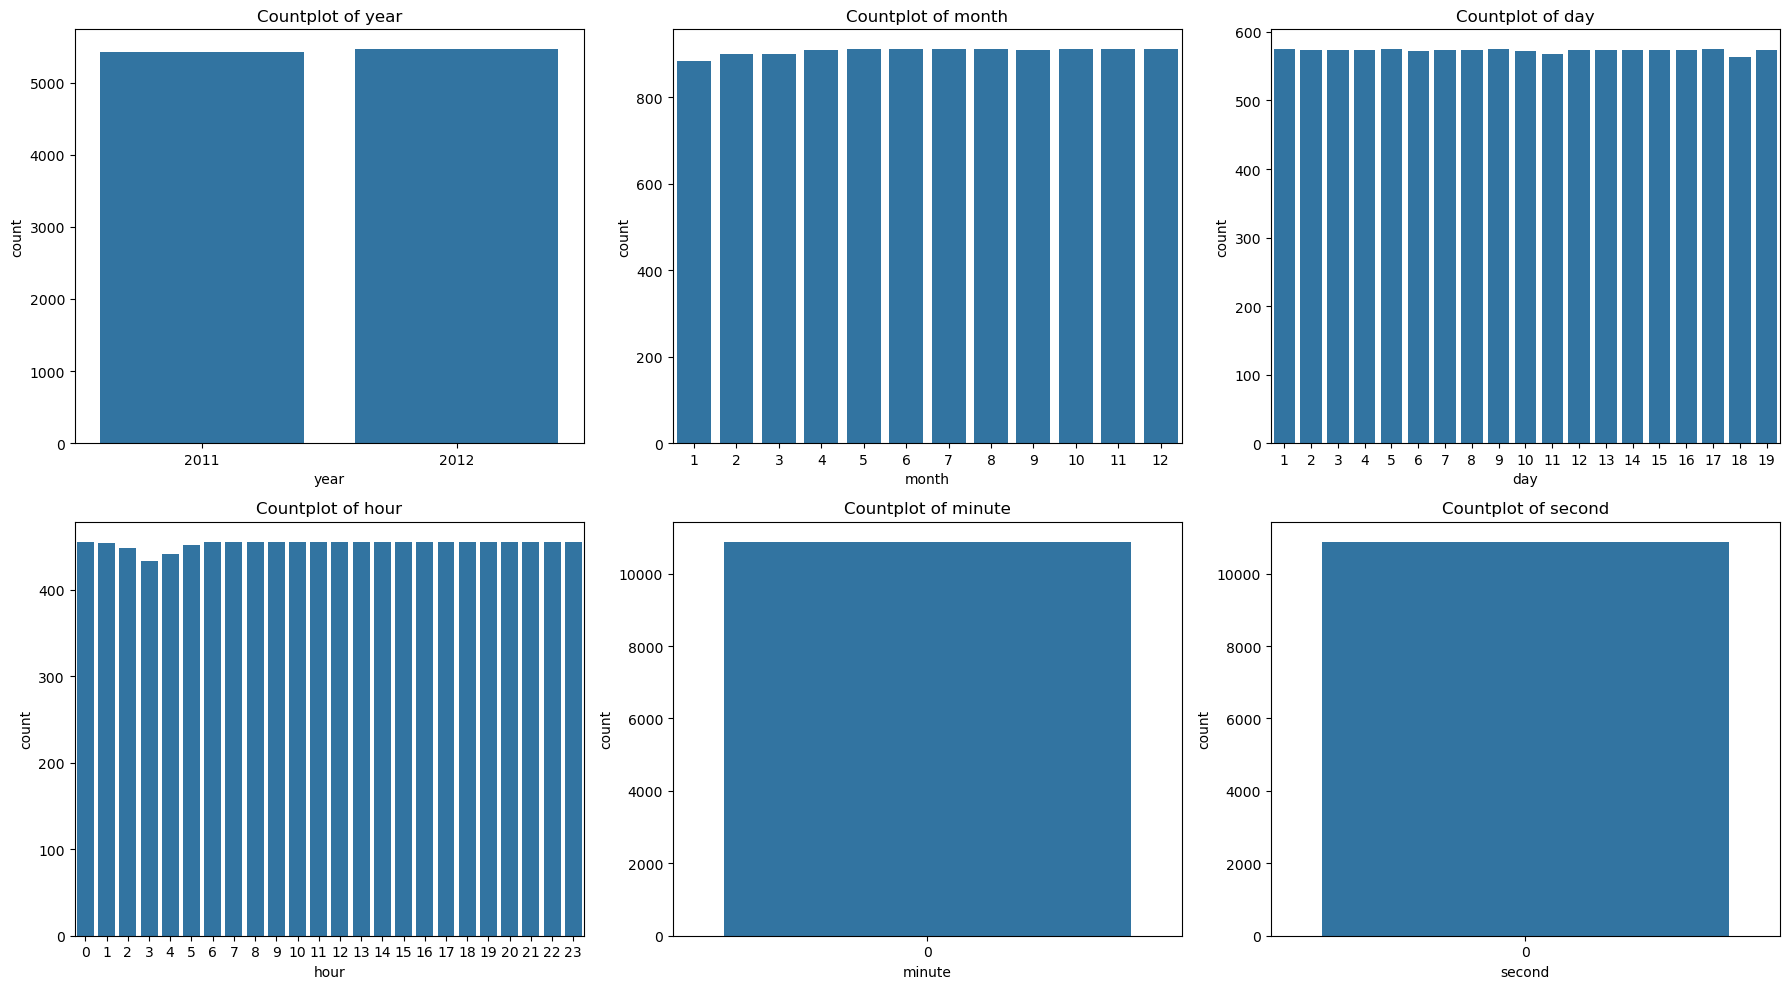

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

In [19]:
features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
X = train[features]
y = train['count']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 19961.901814435438
RMSE: 141.2865946027274


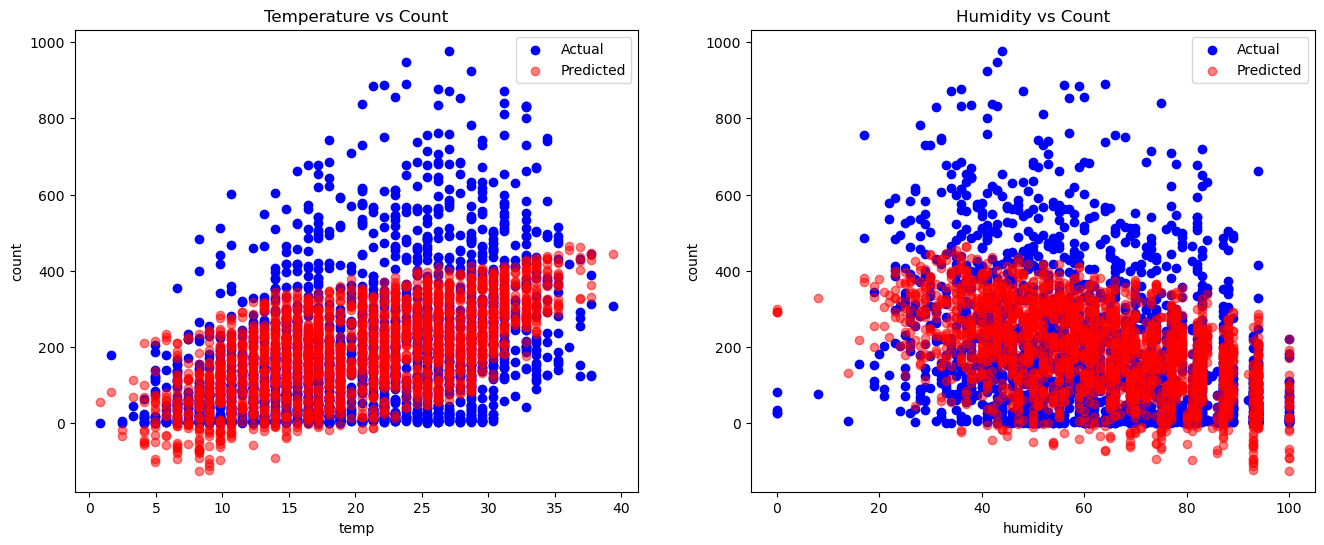

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()

In [23]:
##그의 도발로 인해 색다른 학습법으로 rmse를 조져..성능을 올려보겠다..

기존 선형회귀 모델에서 랜덤 포레스트로 평균을 내봅시당.
    기존 y=wx+b 은 옛날 방식이라고 하네요  최신식 다각도로 랜덤 마인드맵스타일 형식의 사이킷런 모델친구로 조져보겠습니다.

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor#<<<---제미나이가 가르쳐준 좋은모델임.. 알아서 척척척 스스로어린이..
from sklearn.metrics import mean_squared_error

In [27]:
train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv")

In [ ]:
# 근대 여기서 그냥 자료 어디서 랜덤으로 만든줄알았는데 이게 골때리는게 정말 실제 대여자료를 갖고온거같았음
2011년 달력봤는데 주말에 대여량이 평일에 2~3배정도 많은것을보고 아 이거 요일을 입력값에 넣어야 확실한 머신러닝이 가능하겠다 느낌
기존 온도위주의 학습에서 요일별 대여량 중점으로 

In [28]:
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['weekday'] = train['datetime'].dt.weekday

In [29]:
features = ['season', 'holiday', 'workingday', 'weather', 'temp', 
            'atemp', 'humidity', 'windspeed', 'year', 'month', 'hour', 'weekday']   #기존과달리 요일과 연도도 중요하게 랜덤학습을시킴
X = train[features]
y = train['count']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
이건 국룰이래서 20프로만 연습용으로 뺀다..0.2가 국룰이다. 42는 랜덤 이것도 그냥 약속 국룰이다..

In [32]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
rmse = mse ** 0.5

print(f"최종 MSE 값: {mse:.2f}")
print(f"최종 RMSE 값: {rmse:.2f}")

최종 MSE 값: 1530.64
최종 RMSE 값: 39.12


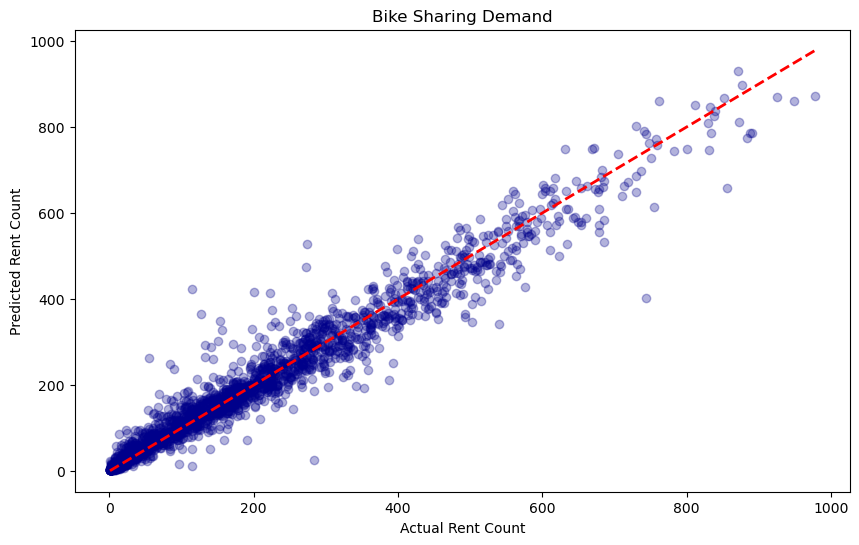

In [46]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.3, color='darkblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Rent Count')
plt.ylabel('Predicted Rent Count')
plt.title('Bike Sharing Demand')
plt.show()

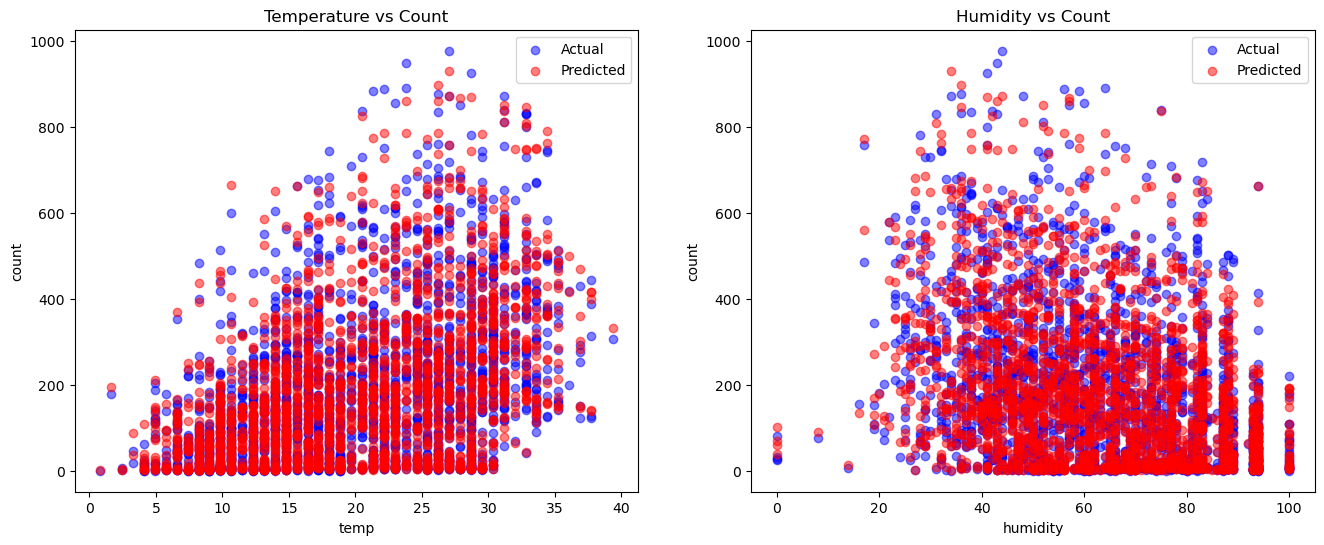

In [41]:
import matplotlib.pyplot as plt


fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual', alpha=0.5)
axs[0].scatter(X_test['temp'], predictions, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()


axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual', alpha=0.5)
axs[1].scatter(X_test['humidity'], predictions, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()

plt.show()

In [ ]:
기존 모델을 랜덤포레스트로 바꾸고 
전처리 과정에서 더욱 세분화하여 복합적으로 해석할수있게 했다.
#기존 요일은 시각화 용도로 주로사용하는걸 끄집어내서 온도에따른 대여량이 아니라
    요일별 휴일이라던지 주말등의 이유로 대여량이 급상승하는걸 파악해서 그걸이용
입력값에 넣으면 주말과 평일에 대여 패턴의 차이가 큰거같아서 성능이 급상승한거같음..
    
    